In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
os.chdir("/content/drive/MyDrive/34132/")

In [3]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 79.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler
from nilearn import plotting
import glob
from tensorflow import keras

In [3]:
scaler = MinMaxScaler()

In [ ]:
img_mask = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-seg.nii')
img_t1c = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii')
img_t1n = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1n.nii')
img_t2f = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2f.nii')
img_t2w = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2w.nii')

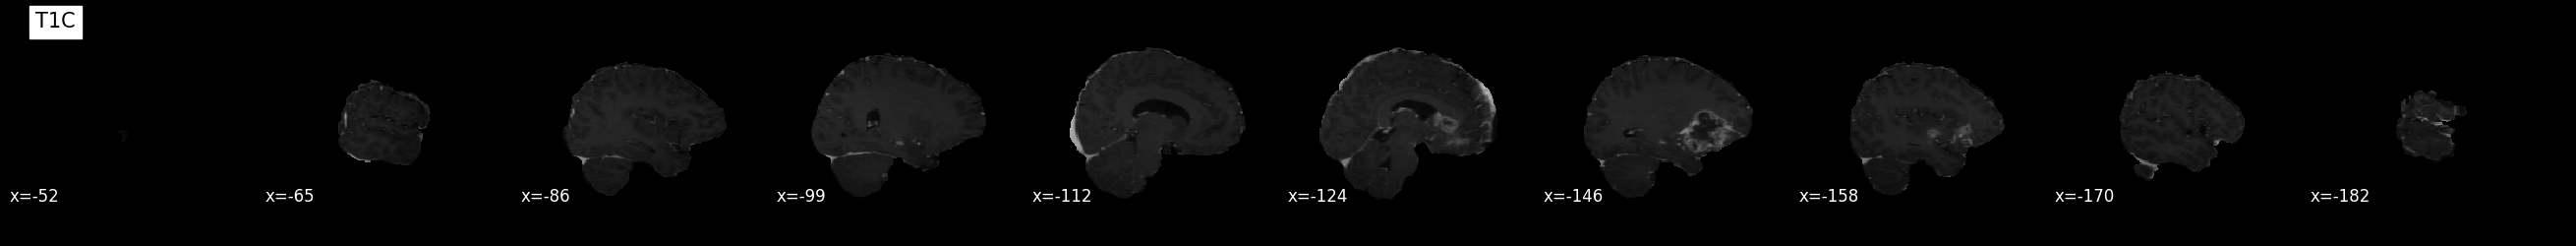

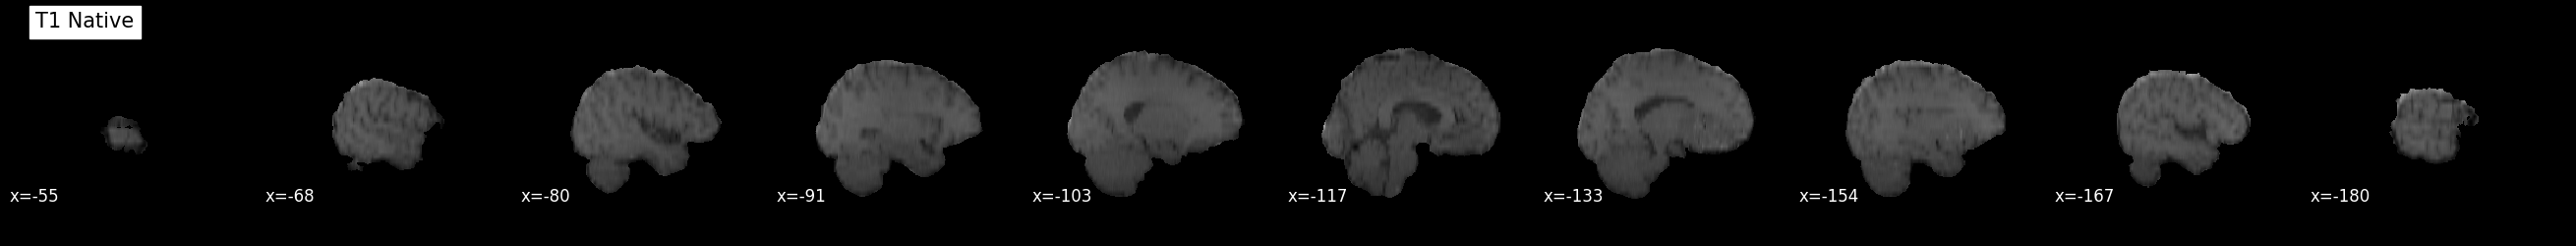

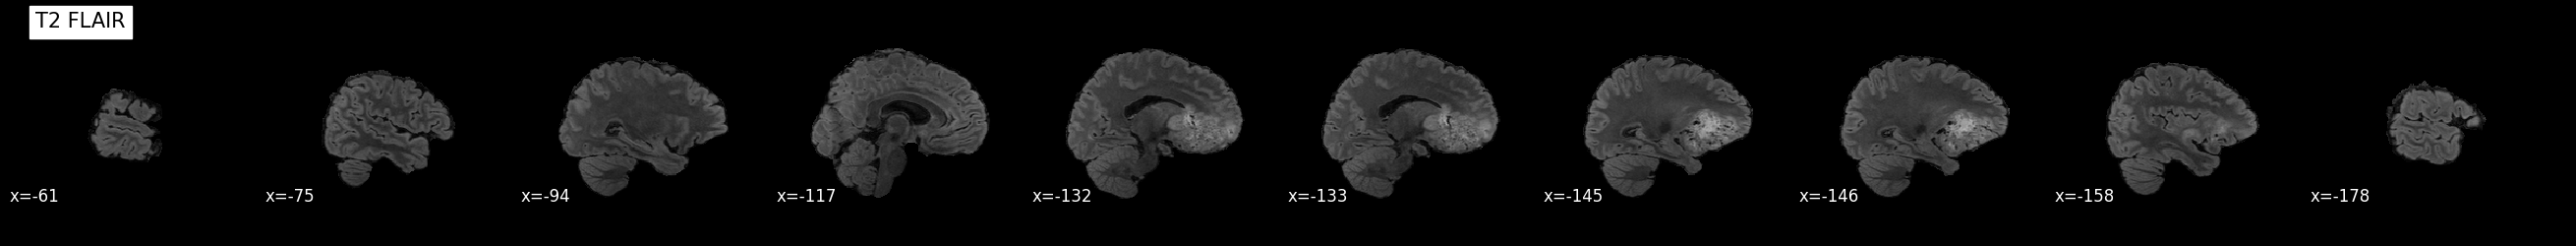

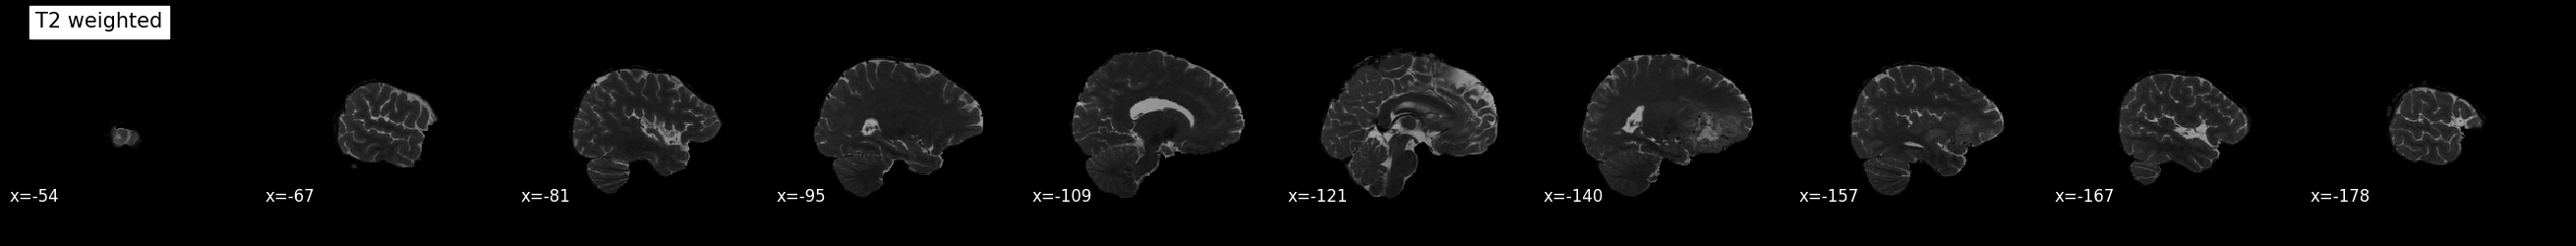

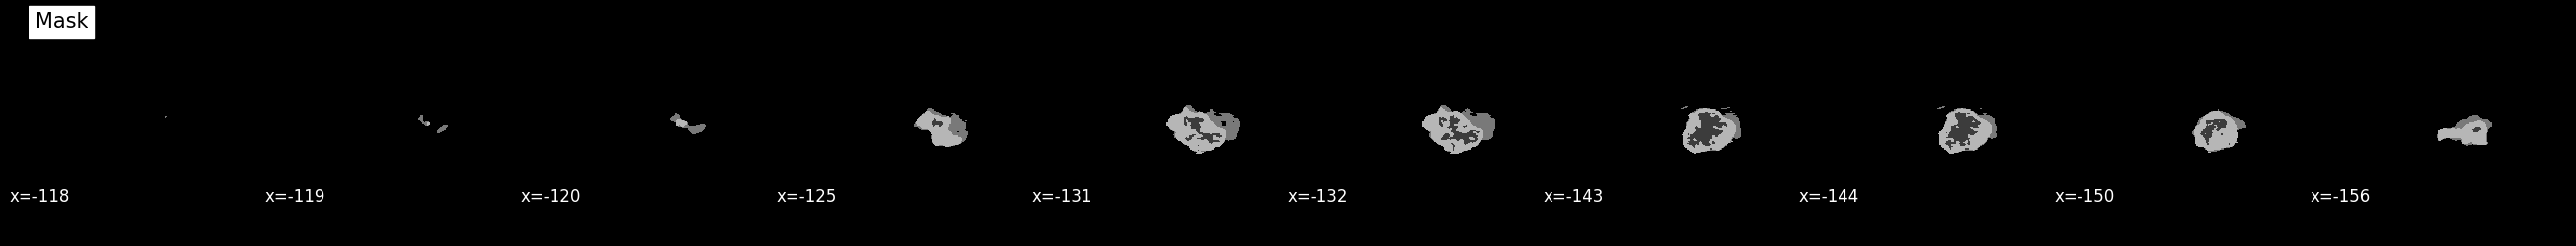

In [ ]:
plotting.plot_anat(img_t1c,annotate=True,title="T1C",display_mode='x', cut_coords=10)
plotting.plot_anat(img_t1n,annotate=True,title="T1 Native",display_mode='x', cut_coords=10)
plotting.plot_anat(img_t2f,annotate=True,title="T2 FLAIR",display_mode='x', cut_coords=10)
plotting.plot_anat(img_t2w,annotate=True,title="T2 weighted",display_mode='x', cut_coords=10)
plotting.plot_anat(img_mask,annotate=True,title="Mask",display_mode='x', cut_coords=10)

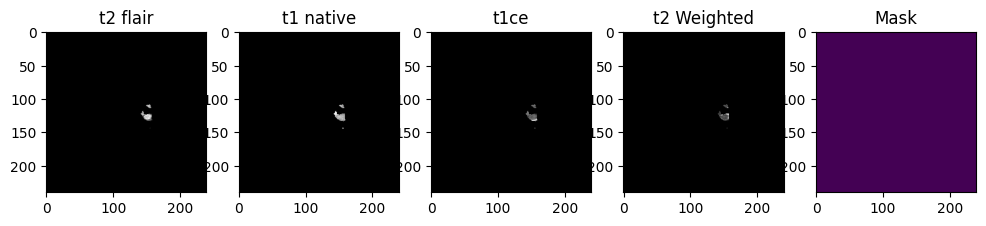

In [ ]:
img_mask = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-seg.nii').get_fdata()
img_t1c = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii').get_fdata()
img_t1n = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1n.nii').get_fdata()
img_t2f = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2f.nii').get_fdata()
img_t2w = nib.load('Brats2023/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2w.nii').get_fdata()

import random
n_slice=random.randint(0, img_mask.shape[2])

plt.figure(figsize=(12, 8))

plt.subplot(151)
plt.imshow(img_t2f[:,:,n_slice], cmap='gray')
plt.title('t2 flair')
plt.subplot(152)
plt.imshow(img_t1n[:,:,n_slice], cmap='gray')
plt.title('t1 native')
plt.subplot(153)
plt.imshow(img_t1c[:,:,n_slice], cmap='gray')
plt.title('t1ce')
plt.subplot(154)
plt.imshow(img_t2w[:,:,n_slice], cmap='gray')
plt.title('t2 Weighted')
plt.subplot(155)
plt.imshow(img_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [ ]:
combined_x = np.stack([img_t2f, img_t1c, img_t2w], axis=3)

combined_x=combined_x[56:184, 56:184, 13:141]
print(img_mask.shape)

img_mask = img_mask[56:184, 56:184, 13:141]
print(img_mask.shape)

(240, 240, 155)
(128, 128, 128)


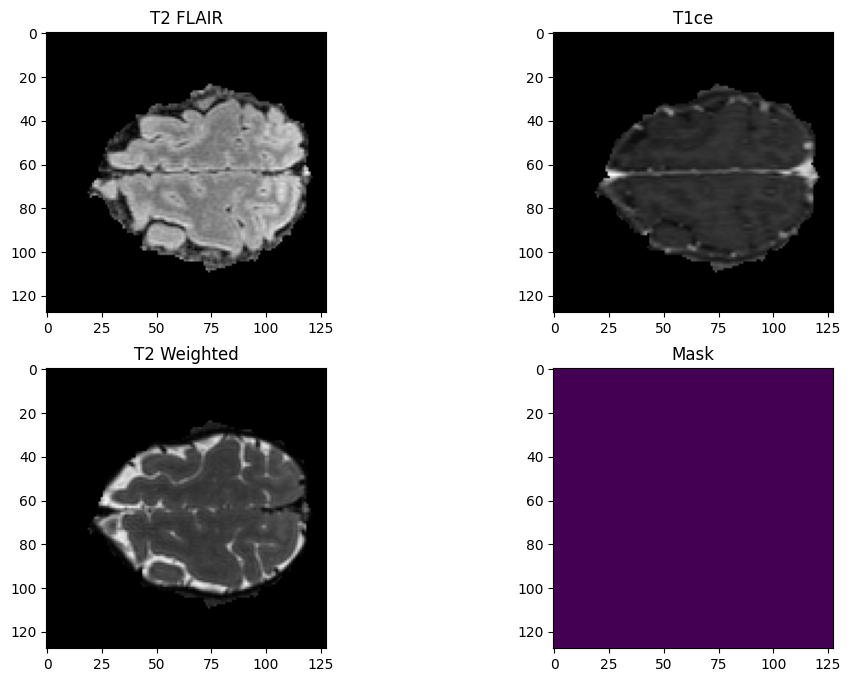

In [ ]:
n_slice=random.randint(0, img_mask.shape[2])

plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined_x[:,:,n_slice, 0], cmap='gray')
plt.title('T2 FLAIR')
plt.subplot(222)
plt.imshow(combined_x[:,:,n_slice, 1], cmap='gray')
plt.title('T1ce')
plt.subplot(223)
plt.imshow(combined_x[:,:,n_slice, 2], cmap='gray')
plt.title('T2 Weighted')
plt.subplot(224)
plt.imshow(img_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [ ]:
t1ce_list = sorted(glob.glob('Brats2023/*/*t1c.nii'))
t2_flair_list = sorted(glob.glob('Brats2023/*/*t2f.nii'))
t2w_list = sorted(glob.glob('Brats2023/*/*t2w.nii'))
mask_list = sorted(glob.glob('Brats2023/*/*seg.nii'))

In [ ]:
import os
save_dir = 'train/images'
os.makedirs(save_dir, exist_ok=True)
save_dir = 'train/masks'
os.makedirs(save_dir, exist_ok=True)
save_dir = 'test/images'
os.makedirs(save_dir, exist_ok=True)
save_dir = 'test/masks'
os.makedirs(save_dir, exist_ok=True)
train_size,test_size = 0,0
total = 0
print(len(t2w_list))
for img in range(len(t2w_list)):
    if total == 200:
        break
    print("Now preparing image and masks number: ", img)
    temp_image_t2w=nib.load(t2w_list[img]).get_fdata()
    temp_image_t2w=scaler.fit_transform(temp_image_t2w.reshape(-1, temp_image_t2w.shape[-1])).reshape(temp_image_t2w.shape)

    temp_image_t1ce=nib.load(t1ce_list[img]).get_fdata()
    temp_image_t1ce=scaler.fit_transform(temp_image_t1ce.reshape(-1, temp_image_t1ce.shape[-1])).reshape(temp_image_t1ce.shape)

    temp_image_flair=nib.load(t2_flair_list[img]).get_fdata()
    temp_image_flair=scaler.fit_transform(temp_image_flair.reshape(-1, temp_image_flair.shape[-1])).reshape(temp_image_flair.shape)

    temp_mask=nib.load(mask_list[img]).get_fdata()
    temp_mask=temp_mask.astype(np.uint8)


    temp_combined_images = np.stack([temp_image_flair, temp_image_t1ce, temp_image_t2w], axis=3)

    temp_combined_images=temp_combined_images[56:184, 56:184, 13:141]
    temp_mask = temp_mask[56:184, 56:184, 13:141]
    val, counts = np.unique(temp_mask, return_counts=True)
    if (1 - (counts[0]/counts.sum())) > 0.01:
        if test_size<30:
            print("Saving in Test folder")
            temp_mask= to_categorical(temp_mask, num_classes=4)
            np.save('test/images/image_'+str(img)+'.npy', temp_combined_images)
            np.save('test/masks/mask_'+str(img)+'.npy', temp_mask)
            test_size = test_size + 1
        else:
            print("Saving in train folder")
            temp_mask= to_categorical(temp_mask, num_classes=4)
            np.save('train/images/image_'+str(img)+'.npy', temp_combined_images)
            np.save('train/masks/mask_'+str(img)+'.npy', temp_mask)
            train_size = train_size + 1
        print(temp_combined_images.shape)
        print(temp_mask.shape)
        total = total + 1
    else:
        print("Image has no useful information ")

625
Now preparing image and masks number:  0
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  1
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  2
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  3
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  4
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  5
Image has no useful information 
Now preparing image and masks number:  6
Image has no useful information 
Now preparing image and masks number:  7
Image has no useful information 
Now preparing image and masks number:  8
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  9
Saving in Test folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  10
Saving in Test folder
(12

(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  82
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  83
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  84
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  85
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  86
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  87
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  88
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  89
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  90
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks numbe

Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  162
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  163
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  164
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  165
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  166
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  167
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  168
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  169
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now preparing image and masks number:  170
Saving in train folder
(128, 128, 128, 3)
(128, 128, 128, 4)
Now

In [4]:
def load_img(img_dir, img_list):
    images=[]
    for i, image_name in enumerate(img_list):
        if (image_name.split('.')[1] == 'npy'):
            image = np.load(img_dir+image_name)
            images.append(image)
    images = np.array(images)

    return(images)

In [5]:
def imageLoader(img_dir, img_list, mask_dir, mask_list, batch_size):
    L = len(img_list)
    while True:
        batch_start = 0
        batch_end = batch_size
        while batch_start < L:
            limit = min(batch_end, L)

            X = load_img(img_dir, img_list[batch_start:limit])
            Y = load_img(mask_dir, mask_list[batch_start:limit])

            yield (X,Y)

            batch_start += batch_size
            batch_end += batch_size

In [6]:
import os
import random
train_img_dir = "train/images/"
train_mask_dir = "train/masks/"

mask_89.npy



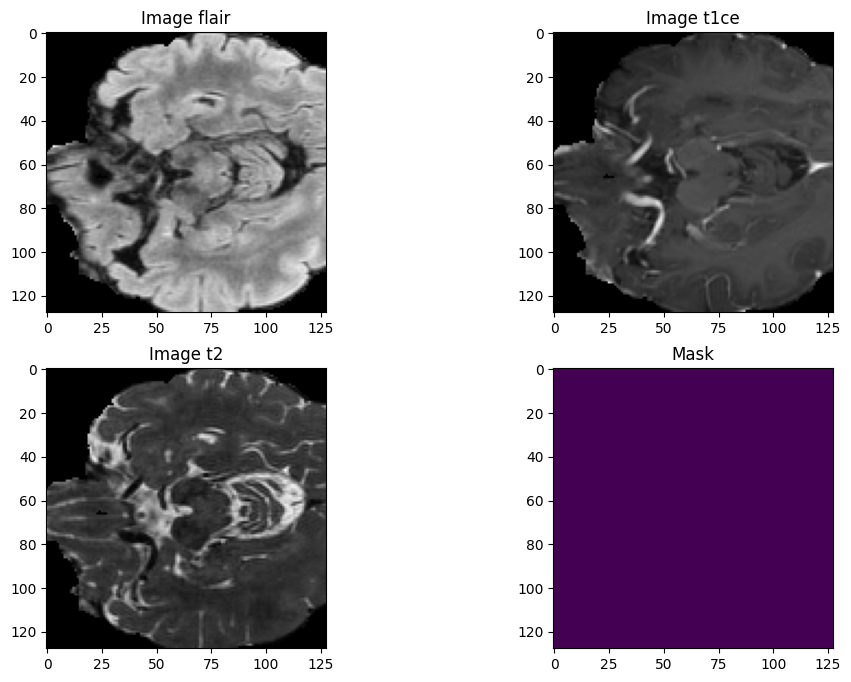

In [9]:
img_list = os.listdir(train_img_dir)
msk_list = os.listdir(train_mask_dir)
num_images = len(os.listdir(train_img_dir))
img_num = random.randint(0,num_images-1)
id = img_list[img_num].split('_')[1].split('.')[0]
print('mask_'+id+'.npy')
test_img = np.load(train_img_dir+img_list[img_num])
print()
test_mask = np.load(train_mask_dir+'mask_'+id+'.npy')
test_mask = np.argmax(test_mask, axis=3)

n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [7]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Dropout
from keras.optimizers import Adam
from keras.metrics import MeanIoU

In [8]:
kernel_initializer =  'uniform'

def Unet_3d(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    s = inputs
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)

    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)

    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)

    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)

    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)

    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)

    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)

    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)

    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)

    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])
    model.summary()

    return model

In [9]:
def extract_number(string):
    id = string.split('_')[1].split('.')[0]
    return int(id)
train_img_dir = "train/images/"
train_mask_dir = "train/masks/"

test_img_dir = "test/images/"
test_mask_dir = "test/masks/"

train_img_list=os.listdir(train_img_dir)
train_mask_list = os.listdir(train_mask_dir)

test_img_list=os.listdir(test_img_dir)
test_mask_list = os.listdir(test_mask_dir)

train_img_list = sorted(train_img_list,key=extract_number)
train_mask_list = sorted(train_mask_list,key=extract_number)
test_img_list = sorted(test_img_list,key=extract_number)
test_mask_list = sorted(test_mask_list,key=extract_number)

In [10]:
batch_size = 1

train_img_datagen = imageLoader(train_img_dir, train_img_list,
                                train_mask_dir, train_mask_list, batch_size)

val_img_datagen = imageLoader(test_img_dir, test_img_list,
                                test_mask_dir, test_mask_list, batch_size)

In [ ]:
img, msk = train_img_datagen.__next__()

img_num = random.randint(0,img.shape[0]-1)
test_img=img[img_num]
id = img_list[img_num].split('_')[1].split('.')[0]

test_mask=msk[img_num]
test_mask=np.argmax(test_mask, axis=3)

n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [11]:
def dice_loss(y_true, y_pred, smooth=1):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3,4])
    union = tf.reduce_sum(y_true, axis=[1,2,3,4]) + tf.reduce_sum(y_pred, axis=[1,2,3,4])
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice

In [12]:
# Define IoU metric properly if not already set in Keras
def iou_metric(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)
    intersection = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
    union = tf.reduce_sum(tf.cast(y_true + y_pred, tf.float32)) - intersection
    return tf.reduce_mean((intersection + 1e-6) / (union + 1e-6))

In [13]:
metrics = [iou_metric]
total_loss = dice_loss
LR = 0.0001
optim = keras.optimizers.Adam(LR)

In [14]:
steps_per_epoch = len(train_img_list)//batch_size
val_steps_per_epoch = len(test_img_list)//batch_size
print(steps_per_epoch,val_steps_per_epoch)

170 30


In [15]:
model = Unet_3d(IMG_HEIGHT=128,
                          IMG_WIDTH=128,
                          IMG_DEPTH=128,
                          IMG_CHANNELS=3,
                          num_classes=4)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 128,  │              0 │ -                      │
│                           │ 3)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d (Conv3D)           │ (None, 128, 128, 128,  │          1,312 │ input_layer[0][0]      │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 128, 128,  │              0 │ conv3d[0][0]           │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_1 (Conv3D)         │ (None, 128, 128, 128,  │          6,928 │ dropout[0][0]          │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d             │ (None, 64, 64, 64, 16) │              0 │ conv3d_1[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_2 (Conv3D)         │ (None, 64, 64, 64, 32) │         13,856 │ max_pooling3d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64, 64, 64, 32) │              0 │ conv3d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_3 (Conv3D)         │ (None, 64, 64, 64, 32) │         27,680 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_1           │ (None, 32, 32, 32, 32) │              0 │ conv3d_3[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_4 (Conv3D)         │ (None, 32, 32, 32, 64) │         55,360 │ max_pooling3d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 32, 64) │              0 │ conv3d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_5 (Conv3D)         │ (None, 32, 32, 32, 64) │        110,656 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_2           │ (None, 16, 16, 16, 64) │              0 │ conv3d_5[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_6 (Conv3D)         │ (None, 16, 16, 16,     │        221,312 │ max_pooling3d_2[0][0]  │
│                           │ 128)                   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 16, 16, 16,     │              0 │ conv3d_6[0][0]         │
│                           │ 128)                   │                │                        │
├──────────────────────

 Total params: 5,645,828 (21.54 MB)

 Trainable params: 5,645,828 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Check if a GPU is available and use it; otherwise, fallback to CPU
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name:
    device = '/gpu:0'
    print(f"Using GPU: {device_name}")
else:
    device = '/cpu:0'
    print("Using CPU")

Using GPU: /device:GPU:0


In [17]:
model.compile(optimizer=optim, loss=total_loss, metrics=metrics)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 128,  │              0 │ -                      │
│                           │ 3)                     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d (Conv3D)           │ (None, 128, 128, 128,  │          1,312 │ input_layer[0][0]      │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 128, 128,  │              0 │ conv3d[0][0]           │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_1 (Conv3D)         │ (None, 128, 128, 128,  │          6,928 │ dropout[0][0]          │
│                           │ 16)                    │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d             │ (None, 64, 64, 64, 16) │              0 │ conv3d_1[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_2 (Conv3D)         │ (None, 64, 64, 64, 32) │         13,856 │ max_pooling3d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64, 64, 64, 32) │              0 │ conv3d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_3 (Conv3D)         │ (None, 64, 64, 64, 32) │         27,680 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_1           │ (None, 32, 32, 32, 32) │              0 │ conv3d_3[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_4 (Conv3D)         │ (None, 32, 32, 32, 64) │         55,360 │ max_pooling3d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 32, 64) │              0 │ conv3d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_5 (Conv3D)         │ (None, 32, 32, 32, 64) │        110,656 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_2           │ (None, 16, 16, 16, 64) │              0 │ conv3d_5[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_6 (Conv3D)         │ (None, 16, 16, 16,     │        221,312 │ max_pooling3d_2[0][0]  │
│                           │ 128)                   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 16, 16, 16,     │              0 │ conv3d_6[0][0]         │
│                           │ 128)                   │                │                        │
├──────────────────────

 Total params: 5,645,828 (21.54 MB)

 Trainable params: 5,645,828 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
print(model.input_shape)
print(model.output_shape)

(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


In [19]:
history=model.fit(train_img_datagen,
          steps_per_epoch=steps_per_epoch,
          epochs=5,
          verbose=1,
          validation_data=val_img_datagen,
          validation_steps=val_steps_per_epoch,
          )

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - iou_metric: 0.0277 - loss: 0.3221 - val_iou_metric: 7.1990e-12 - val_loss: 0.0459
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - iou_metric: 6.6374e-12 - loss: 0.0471 - val_iou_metric: 7.1990e-12 - val_loss: 0.0459
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 440s 3s/step - iou_metric: 6.6379e-12 - loss: 0.0471 - val_iou_metric: 7.1990e-12 - val_loss: 0.0459
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step - iou_metric: 6.6379e-12 - loss: 0.0471 - val_iou_metric: 7.1990e-12 - val_loss: 0.0459
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - iou_metric: 6.6380e-12 - loss: 0.0471 - val_iou_metric: 7.1990e-12 - val_loss: 0.0459


In [20]:
from keras.metrics import MeanIoU

batch_size=1
test_img_datagen = imageLoader(test_img_dir, test_img_list,
                                test_mask_dir, test_mask_list, batch_size)

test_image_batch, test_mask_batch = test_img_datagen.__next__()

test_mask_batch_argmax = np.argmax(test_mask_batch, axis=4)
test_pred_batch = model.predict(test_image_batch)
test_pred_batch_argmax = np.argmax(test_pred_batch, axis=4)

n_classes = 4
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(test_pred_batch_argmax, test_mask_batch_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Mean IoU = 0.24344063
